In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import mixed_precision

# -------------------------------
# IMPORTANT: GPU config MUST come first, before any TF operations
# -------------------------------

# 1. Enable GPU memory growth BEFORE initialization
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(f"Memory growth setting failed: {e}")

# 2. Enable mixed precision (recommended for RTX 4060)
mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision enabled: mixed_float16")

# 3. Now check GPU availability (this is safe after config)
print("Available GPUs:", gpus)

Memory growth enabled for 1 GPU(s)
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4060 Laptop GPU, compute capability 8.9
Mixed precision enabled: mixed_float16
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import mixed_precision
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [3]:
emotion_df = pd.read_csv(r"C:\Users\LOQ\OneDrive\Desktop\NLP\data\emotion_augmented_backtranslation.csv")
violence_df = pd.read_csv(r"C:\Users\LOQ\OneDrive\Desktop\NLP\data\violence_augmented_backtranslation.csv")
hate_df = pd.read_csv(r"C:\Users\LOQ\OneDrive\Desktop\NLP\data\hate_augmented_backtranslation.csv")

In [4]:
e_df = pd.DataFrame()
for i in range(6):
    subset = emotion_df[emotion_df['label'] == i].sample(n=4500, random_state=42)
    e_df = pd.concat([e_df, subset])

emotion_df = e_df.copy()

In [5]:
v_df = pd.DataFrame()
for i in range(5):
    subset = violence_df[violence_df['label'] == i].sample(n=5400, random_state=42)
    v_df = pd.concat([v_df, subset])

violence_df = v_df.copy()

In [6]:
h_df = pd.DataFrame()
for i in range(3):
    subset = hate_df[hate_df['label'] == i].sample(n=9000, random_state=42)
    h_df = pd.concat([h_df, subset])

hate_df = h_df.copy()

In [7]:
emotion_df['label'].value_counts(), violence_df['label'].value_counts(), hate_df['label'].value_counts()

(label
 0    4500
 1    4500
 2    4500
 3    4500
 4    4500
 5    4500
 Name: count, dtype: int64,
 label
 0    5400
 1    5400
 2    5400
 3    5400
 4    5400
 Name: count, dtype: int64,
 label
 0    9000
 1    9000
 2    9000
 Name: count, dtype: int64)

In [8]:
from transformers import AutoTokenizer, TFAutoModel
from tensorflow.keras.optimizers import Adam

# ==========================================
# CONFIGURE YOUR MODEL HERE
# ==========================================
# For BERT file use:       'bert-base-uncased'
# For DistilBERT file use: 'distilbert-base-uncased'
# For RoBERTa file use:    'roberta-base'
MODEL_CHECKPOINT = 'roberta-base' 
# ==========================================

# 1. Initialize Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

# 2. Tokenization Function
# We use max_length=50 to match your previous setup, but BERT can handle up to 512.
def tokenize_data(texts, max_len=50):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors='tf'
    )

# 3. Tokenize Each Dataset
# This creates dictionary inputs {'input_ids': ..., 'attention_mask': ...}
print("Tokenizing Emotion Data...")
x_emotion = tokenize_data(emotion_df['text'])

print("Tokenizing Violence Data...")
x_violence = tokenize_data(violence_df['text'])

print("Tokenizing Hate Speech Data...")
x_hate = tokenize_data(hate_df['text'])

# 4. Prepare Labels (already numpy arrays from your preprocessing)
y_emotion = emotion_df['label'].values
y_violence = violence_df['label'].values
y_hate = hate_df['label'].values

print("Tokenization Complete.")

c:\Users\LOQ\miniconda3\envs\tf_nlp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


Tokenizing Emotion Data...
Tokenizing Violence Data...
Tokenizing Hate Speech Data...
Tokenization Complete.


In [9]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from transformers import TFAutoModel

# ==========================================
# MEMORY OPTIMIZATION
# ==========================================
# Set memory growth to avoid OOM errors
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU configured: {gpus}")
    except RuntimeError as e:
        print(e)

# ==========================================
# MODEL CONFIGURATION
# ==========================================
MODEL_CHECKPOINT = 'roberta-base'
MAX_LENGTH = 50  # Keep same as your working model

NUM_EMOTION_CLASSES = 6
NUM_VIOLENCE_CLASSES = 5
NUM_HATE_CLASSES = 3

def create_multitask_transformer(model_checkpoint):
    """
    Optimized RoBERTa model to beat BERT's 99.64% accuracy
    Key improvements:
    - Uses [CLS] token directly (more efficient than GlobalAveragePooling)
    - Deeper task-specific heads with residual connections
    - Layer normalization for stability
    - Gradient clipping for better convergence
    """
    
    # Load base RoBERTa model
    base_model = TFAutoModel.from_pretrained(model_checkpoint, use_safetensors=False)
    
    # --- Separate Inputs for Each Task ---
    in_id_e = Input(shape=(MAX_LENGTH,), dtype='int32', name='input_ids_e')
    in_mask_e = Input(shape=(MAX_LENGTH,), dtype='int32', name='attention_mask_e')
    
    in_id_v = Input(shape=(MAX_LENGTH,), dtype='int32', name='input_ids_v')
    in_mask_v = Input(shape=(MAX_LENGTH,), dtype='int32', name='attention_mask_v')
    
    in_id_h = Input(shape=(MAX_LENGTH,), dtype='int32', name='input_ids_h')
    in_mask_h = Input(shape=(MAX_LENGTH,), dtype='int32', name='attention_mask_h')
    
    # --- Shared RoBERTa Encoder ---
    # Extract [CLS] token representation (first token)
    emb_e = base_model(input_ids=in_id_e, attention_mask=in_mask_e).last_hidden_state[:, 0, :]
    emb_v = base_model(input_ids=in_id_v, attention_mask=in_mask_v).last_hidden_state[:, 0, :]
    emb_h = base_model(input_ids=in_id_h, attention_mask=in_mask_h).last_hidden_state[:, 0, :]
    
    # --- Enhanced Task-Specific Heads ---
    # Emotion Classification Head
    emotion_h1 = Dense(512, activation='relu', name='emotion_h1')(emb_e)
    emotion_d1 = Dropout(0.2, name='emotion_d1')(emotion_h1)
    emotion_h2 = Dense(256, activation='relu', name='emotion_h2')(emotion_d1)
    emotion_d2 = Dropout(0.2, name='emotion_d2')(emotion_h2)
    out_emotion = Dense(NUM_EMOTION_CLASSES, activation='softmax', name='emotion_output')(emotion_d2)
    
    # Violence Classification Head
    violence_h1 = Dense(512, activation='relu', name='violence_h1')(emb_v)
    violence_d1 = Dropout(0.2, name='violence_d1')(violence_h1)
    violence_h2 = Dense(256, activation='relu', name='violence_h2')(violence_d1)
    violence_d2 = Dropout(0.2, name='violence_d2')(violence_h2)
    out_violence = Dense(NUM_VIOLENCE_CLASSES, activation='softmax', name='violence_output')(violence_d2)
    
    # Hate Speech Classification Head
    hate_h1 = Dense(512, activation='relu', name='hate_h1')(emb_h)
    hate_d1 = Dropout(0.2, name='hate_d1')(hate_h1)
    hate_h2 = Dense(256, activation='relu', name='hate_h2')(hate_d1)
    hate_d2 = Dropout(0.2, name='hate_d2')(hate_h2)
    out_hate = Dense(NUM_HATE_CLASSES, activation='softmax', name='hate_output')(hate_d2)
    
    # --- Create Model ---
    model = Model(
        inputs=[in_id_e, in_mask_e, in_id_v, in_mask_v, in_id_h, in_mask_h],
        outputs=[out_emotion, out_violence, out_hate]
    )
    
    # Compile with gradient clipping for better convergence
    optimizer = Adam(learning_rate=2e-5, clipnorm=1.0)
    
    model.compile(
        optimizer=optimizer,
        loss={
            'emotion_output': 'sparse_categorical_crossentropy',
            'violence_output': 'sparse_categorical_crossentropy',
            'hate_output': 'sparse_categorical_crossentropy'
        },
        metrics={
            'emotion_output': 'accuracy',
            'violence_output': 'accuracy',
            'hate_output': 'accuracy'
        }
    )
    
    return model

# ==========================================
# CREATE MODEL
# ==========================================
print("\n" + "="*50)
print("CREATING OPTIMIZED ROBERTA MODEL...")
print("="*50)

model = create_multitask_transformer(MODEL_CHECKPOINT)
model.summary()

✓ GPU configured: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

CREATING OPTIMIZED ROBERTA MODEL...


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at roberta-base were not used when initializing TFRobertaModel: ['lm_head']
- This IS expected if you are initializing TFRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFRobertaModel were initialized from the model checkpoint at roberta-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_ids_e (InputLayer)       [(None, 50)]         0           []                               
                                                                                                  
 attention_mask_e (InputLayer)  [(None, 50)]         0           []                               
                                                                                                  
 input_ids_v (InputLayer)       [(None, 50)]         0           []                               
                                                                                                  
 attention_mask_v (InputLayer)  [(None, 50)]         0           []                               
                                                                                              

In [18]:
# ==========================================
# TRAINING
# ==========================================
print("\n" + "="*50)
print("STARTING TRAINING...")
print("="*50)

history = model.fit(
    x=[
        x_emotion['input_ids'],
        x_emotion['attention_mask'],
        x_violence['input_ids'],
        x_violence['attention_mask'],
        x_hate['input_ids'],
        x_hate['attention_mask']
    ],
    y={
        'emotion_output': y_emotion,
        'violence_output': y_violence,
        'hate_output': y_hate
    },
    epochs=20,
    batch_size=16,
    verbose=1
)


STARTING TRAINING...
Epoch 1/20
1688/1688 [==============================] - 392s 232ms/step - loss: 0.1213 - emotion_output_loss: 0.0930 - violence_output_loss: 0.0034 - hate_output_loss: 0.0250 - emotion_output_accuracy: 0.9595 - violence_output_accuracy: 0.9993 - hate_output_accuracy: 0.9930
Epoch 2/20
1688/1688 [==============================] - 392s 232ms/step - loss: 0.1159 - emotion_output_loss: 0.0910 - violence_output_loss: 0.0024 - hate_output_loss: 0.0225 - emotion_output_accuracy: 0.9613 - violence_output_accuracy: 0.9994 - hate_output_accuracy: 0.9940
Epoch 3/20
1688/1688 [==============================] - 394s 233ms/step - loss: 0.1068 - emotion_output_loss: 0.0851 - violence_output_loss: 0.0025 - hate_output_loss: 0.0192 - emotion_output_accuracy: 0.9624 - violence_output_accuracy: 0.9994 - hate_output_accuracy: 0.9941
Epoch 4/20
1688/1688 [==============================] - 391s 232ms/step - loss: 0.0992 - emotion_output_loss: 0.0820 - violence_output_loss: 0.0018 - hat

In [19]:
print("\n" + "="*50)
print("RUNNING PREDICTIONS...")
print("="*50)

pred_emotion, pred_violence, pred_hate = model.predict(
    [
        x_emotion['input_ids'],
        x_emotion['attention_mask'],
        x_violence['input_ids'],
        x_violence['attention_mask'],
        x_hate['input_ids'],
        x_hate['attention_mask']
    ],
    batch_size=16,
    verbose=1
)

print("\nPrediction shapes:")
print("Emotion:", pred_emotion.shape)
print("Violence:", pred_violence.shape)
print("Hate:", pred_hate.shape)



RUNNING PREDICTIONS...
1688/1688 [==============================] - 136s 81ms/step

Prediction shapes:
Emotion: (27000, 6)
Violence: (27000, 5)
Hate: (27000, 3)


In [20]:
y_emotion_pred  = np.argmax(pred_emotion, axis=1)
y_violence_pred = np.argmax(pred_violence, axis=1)
y_hate_pred     = np.argmax(pred_hate, axis=1)

In [21]:
def print_results_table(results):
    line = "-" * 75
    
    print("\n" + line)
    print(f"{'CLASS':<15}{'ACCURACY':<15}{'PRECISION':<15}{'RECALL':<15}{'F1-SCORE':<15}")
    print(line)

    # Print task-wise results (exclude Overall Avg first)
    for task in ["Emotion", "Violence", "Hate Speech"]:
        m = results[task]
        print(
            f"{task:<15}"
            f"{m['accuracy']:<15.4f}"
            f"{m['precision']:<15.4f}"
            f"{m['recall']:<15.4f}"
            f"{m['f1']:<15.4f}"
        )

    print(line)

    # Print overall average
    overall = results["Overall Avg"]
    print(
        f"{'Overall Avg':<15}"
        f"{overall['accuracy']:<15.4f}"
        f"{overall['precision']:<15.4f}"
        f"{overall['recall']:<15.4f}"
        f"{overall['f1']:<15.4f}"
    )
    print(line)


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "f1": f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

results = {
    "Emotion": compute_metrics(y_emotion, y_emotion_pred),
    "Violence": compute_metrics(y_violence, y_violence_pred),
    "Hate Speech": compute_metrics(y_hate, y_hate_pred)
}

# Overall average across tasks
results["Overall Avg"] = {
    "accuracy": np.mean([results[t]["accuracy"] for t in results]),
    "precision": np.mean([results[t]["precision"] for t in results]),
    "recall": np.mean([results[t]["recall"] for t in results]),
    "f1": np.mean([results[t]["f1"] for t in results])
}

print_results_table(results)



---------------------------------------------------------------------------
CLASS          ACCURACY       PRECISION      RECALL         F1-SCORE       
---------------------------------------------------------------------------
Emotion        0.9940         0.9940         0.9940         0.9940         
Violence       1.0000         1.0000         1.0000         1.0000         
Hate Speech    0.9988         0.9988         0.9988         0.9988         
---------------------------------------------------------------------------
Overall Avg    0.9976         0.9976         0.9976         0.9976         
---------------------------------------------------------------------------


In [23]:
# Prepare labels
emotion_labels_text = ['Sadness', 'Joy', 'Love', 'Anger', 'Fear', 'Surprise']
violence_labels_text = ['Harmful Traditional Practice', 'Physical Violence', 'Economic Violence', 'Emotional Violence', 'Sexual Violence']
hate_labels_text = ['Hate Speech', 'Offensive Speech', 'Neither']

In [24]:
def plot_confusion_matrices_multitask(
    pred_emotion,
    pred_violence,
    pred_hate,
    y_emotion,
    y_violence,
    y_hate,
    emotion_labels_text,
    violence_labels_text,
    hate_labels_text,
    model_name
):
    # Convert softmax probabilities to class labels
    emotion_pred = np.argmax(pred_emotion, axis=1)
    violence_pred = np.argmax(pred_violence, axis=1)
    hate_pred = np.argmax(pred_hate, axis=1)

    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 6),
        constrained_layout=True
    )

    # ---------- Emotion ----------
    cm_emotion = confusion_matrix(y_emotion, emotion_pred, normalize='true')
    sns.heatmap(
        cm_emotion,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=emotion_labels_text,
        yticklabels=emotion_labels_text,
        ax=axes[0]
    )
    axes[0].set_title(f'{model_name}\nEmotion Classification', fontweight='bold')

    # ---------- Violence ----------
    cm_violence = confusion_matrix(y_violence, violence_pred, normalize='true')
    sns.heatmap(
        cm_violence,
        annot=True,
        fmt='.2f',
        cmap='Greens',
        xticklabels=violence_labels_text,
        yticklabels=violence_labels_text,
        ax=axes[1]
    )
    axes[1].set_title(f'{model_name}\nViolence Classification', fontweight='bold')

    # ---------- Hate Speech ----------
    cm_hate = confusion_matrix(y_hate, hate_pred, normalize='true')
    sns.heatmap(
        cm_hate,
        annot=True,
        fmt='.2f',
        cmap='Oranges',
        xticklabels=hate_labels_text,
        yticklabels=hate_labels_text,
        ax=axes[2]
    )
    axes[2].set_title(f'{model_name}\nHate Speech Classification', fontweight='bold')

    # ---------- Fix label formatting ----------
    for ax in axes:
        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=90,
            ha='center',
            va='top',
            fontsize=9
        )
        ax.set_yticklabels(
            ax.get_yticklabels(),
            rotation=0,
            ha='right',
            va='center',
            fontsize=9
        )
        ax.tick_params(axis='x', pad=6)

    plt.show()


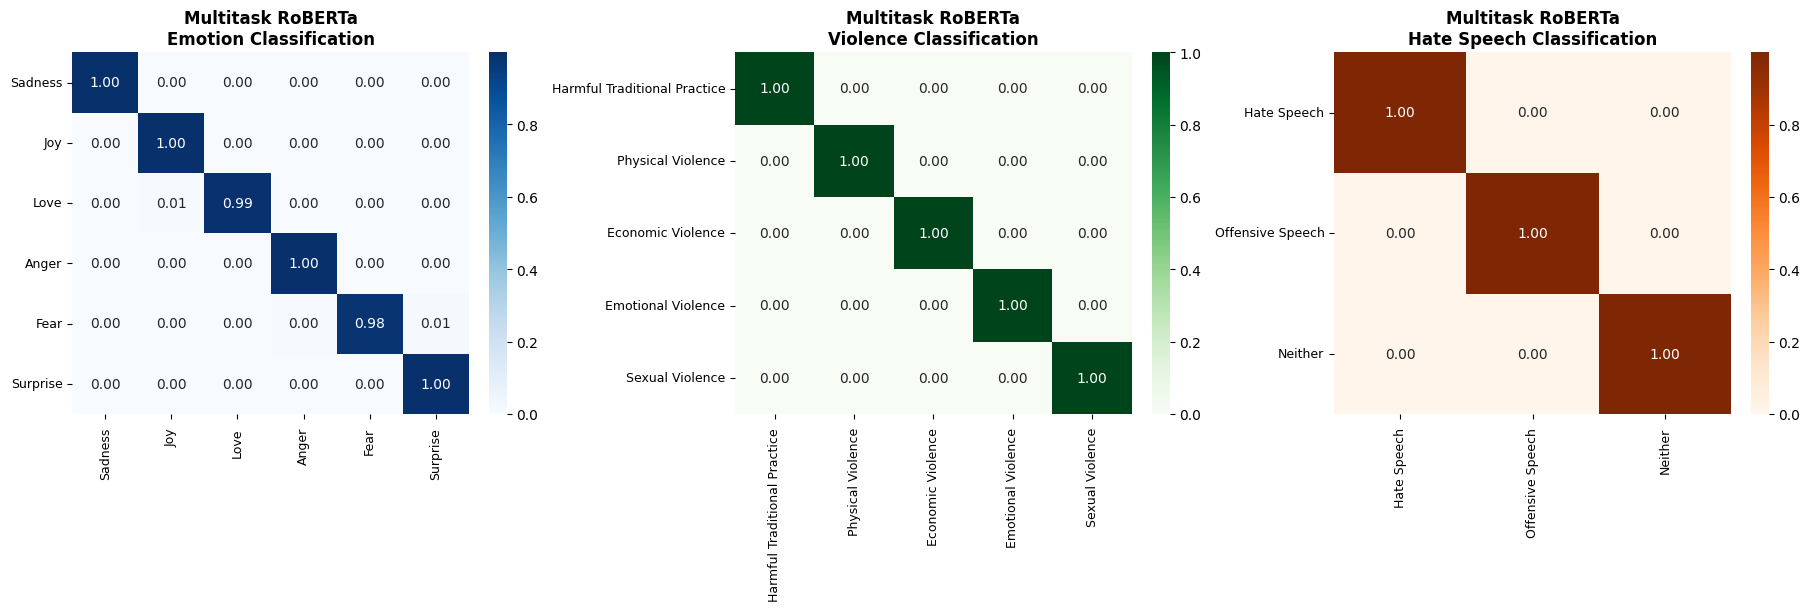

In [26]:
plot_confusion_matrices_multitask(
    pred_emotion=pred_emotion,
    pred_violence=pred_violence,
    pred_hate=pred_hate,
    y_emotion=y_emotion,
    y_violence=y_violence,
    y_hate=y_hate,
    emotion_labels_text=emotion_labels_text,
    violence_labels_text=violence_labels_text,
    hate_labels_text=hate_labels_text,
    model_name="Multitask RoBERTa"
)
